In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)
import warnings
warnings.filterwarnings('ignore')

# Configurar estilo
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Librerías importadas correctamente")

✓ Librerías importadas correctamente


In [3]:
from pathlib import Path
import warnings

import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

csv_path = Path("weatherAUS.csv")

if not csv_path.exists():
    try:
        import kagglehub
        dataset_path = Path(kagglehub.dataset_download("jsphyg/weather-dataset-rattle-package"))
        candidate = dataset_path / "weatherAUS.csv"
        if candidate.exists():
            csv_path = candidate
        else:
            raise FileNotFoundError("weatherAUS.csv no encontrado en el dataset descargado.")
    except Exception as e:
        raise FileNotFoundError(
            "No se encontro weatherAUS.csv en la carpeta actual y no fue posible descargarlo desde Kaggle. "
            "Solucion: coloca weatherAUS.csv en esta carpeta o configura acceso a Kaggle."
        ) from e

df = pd.read_csv(csv_path)
print(f"Dataset cargado desde: {csv_path}")
print(f"Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}")
df.head()

Dataset cargado desde: /Users/juan/.cache/kagglehub/datasets/jsphyg/weather-dataset-rattle-package/versions/2/weatherAUS.csv
Filas: 145,460 | Columnas: 23


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [4]:
# Conteo de todas las categorías distintas
df['RainTomorrow'].value_counts()
#df.columns

RainTomorrow
No     110316
Yes     31877
Name: count, dtype: int64

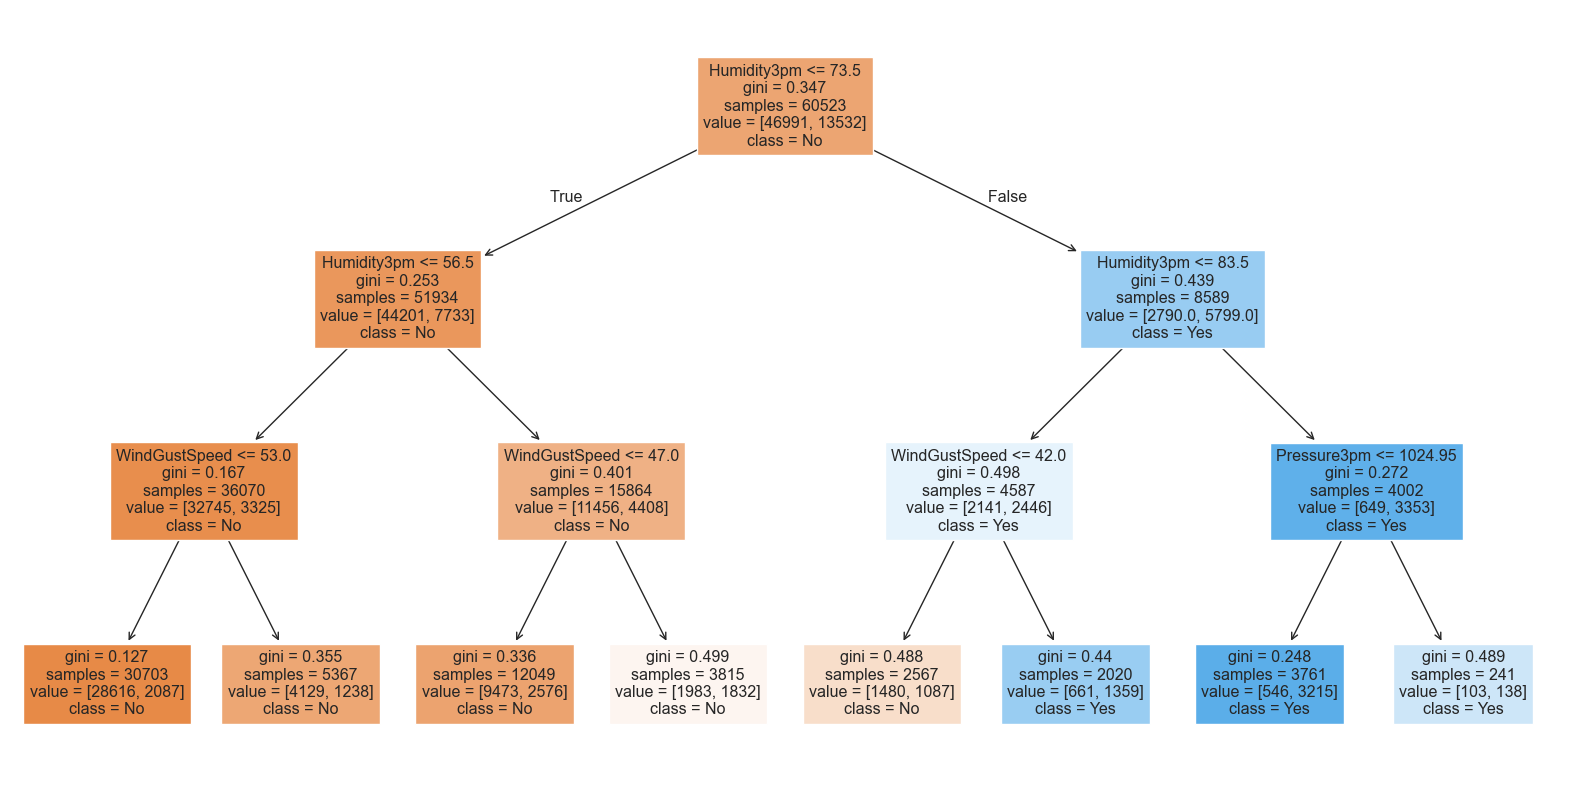

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Reemplazar valores '?' por NaN
df = df.replace("?", np.nan)

# Eliminar filas donde la etiqueta no exista
df = df[df['RainTomorrow'].notna()]

# Seleccionar variables
X = df[['MinTemp','WindGustSpeed','Humidity3pm','Pressure3pm']]
y = df['RainTomorrow']

# Eliminar filas con NaN en las variables
X = X.apply(pd.to_numeric, errors='coerce')
X = X.dropna()

# Mantener las mismas filas en y
y = y.loc[X.index]

# Codificar etiquetas
le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.5, random_state=42)

clf = DecisionTreeClassifier(max_depth=3)
clf.fit(X_train, y_train)

plt.figure(figsize=(20,10))
plot_tree(clf, feature_names=X.columns, class_names=le.classes_, filled=True)
plt.show()

Precisión del modelo: 0.8332397065626859


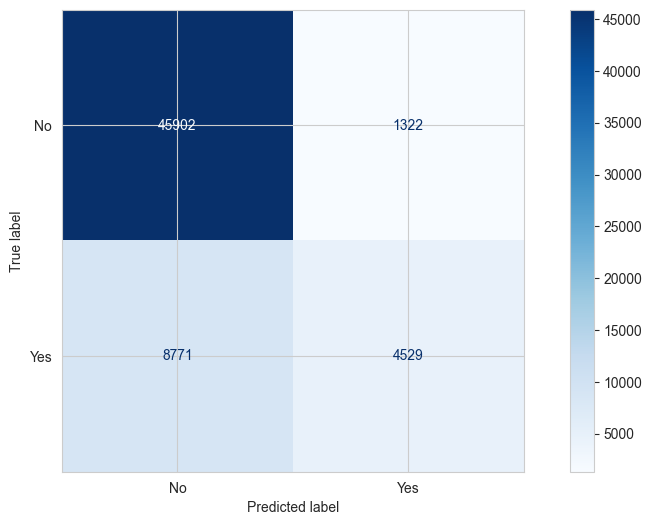

In [6]:
from sklearn.metrics import ConfusionMatrixDisplay
# Predicciones
y_pred = clf.predict(X_test)

# Precisión
accuracy = accuracy_score(y_test, y_pred)
print("Precisión del modelo:", accuracy)


ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=le.classes_,
    cmap="Blues"
)
plt.show()

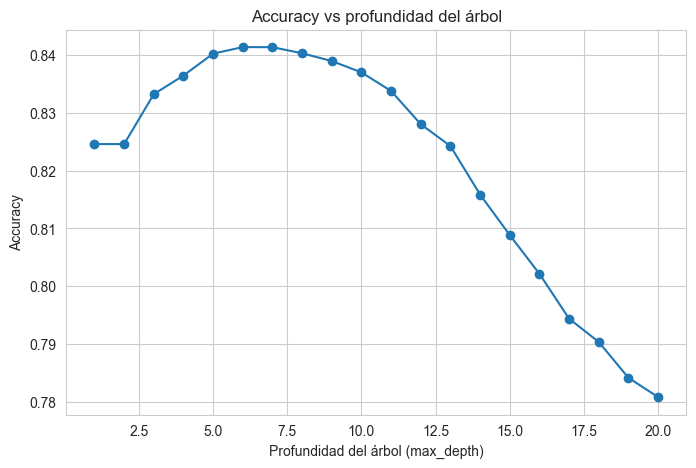

In [7]:
depths = range(1, 21)
scores = []

for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    scores.append(acc)


plt.figure(figsize=(8,5))
plt.plot(depths, scores, marker='o')

plt.xlabel("Profundidad del árbol (max_depth)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs profundidad del árbol")

plt.grid(True)
plt.show()

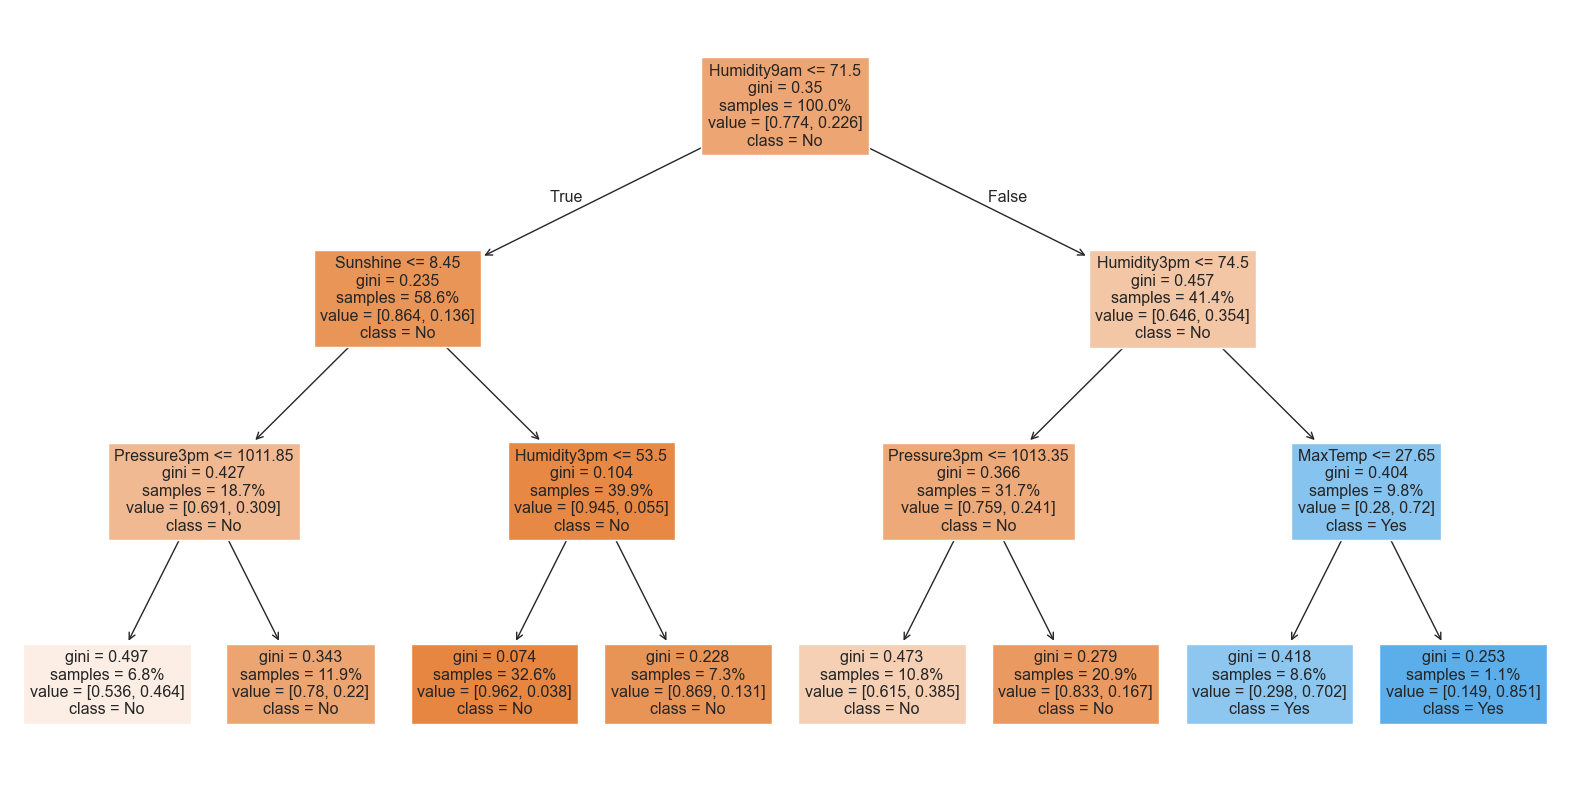

In [8]:
# Seleccionar variables
X = df[['MinTemp', 'MaxTemp', 'Rainfall','Sunshine', 'Humidity9am', 'Humidity3pm',
        'Pressure3pm', 'Cloud3pm']]
y = df['RainTomorrow']

# Eliminar filas con NaN en las variables
X = X.apply(pd.to_numeric, errors='coerce')
X = X.dropna()

# Mantener las mismas filas en y
y = y.loc[X.index]

# Codificar etiquetas
le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.5, random_state=42)

clf = DecisionTreeClassifier(max_depth=3,max_features='sqrt',random_state=42)
clf.fit(X_train, y_train)

plt.figure(figsize=(20,10))
plot_tree(clf, feature_names=X.columns, class_names=le.classes_, filled=True,proportion=True)
plt.show()

Precisión del modelo: 0.8175690367471189


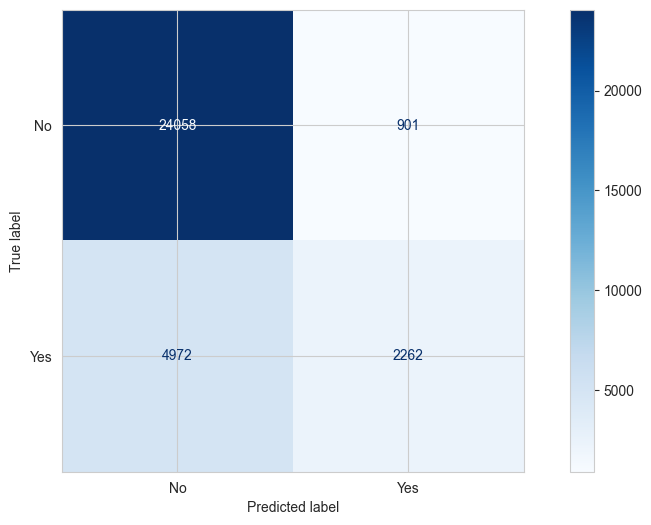

In [9]:
# Predicciones
y_pred = clf.predict(X_test)

# Precisión
accuracy = accuracy_score(y_test, y_pred)
print("Precisión del modelo:", accuracy)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=le.classes_,
    cmap="Blues"
)
plt.show()

In [10]:
# ¿Cuáles fueron las variables más útiles?
importances = pd.DataFrame({'feature': X.columns, 'importance': clf.feature_importances_})
print("\nImportancia de las variables:")
print(importances.sort_values(by='importance', ascending=False))



Importancia de las variables:
       feature  importance
5  Humidity3pm    0.404490
4  Humidity9am    0.264468
3     Sunshine    0.188888
6  Pressure3pm    0.136942
1      MaxTemp    0.005212
0      MinTemp    0.000000
2     Rainfall    0.000000
7     Cloud3pm    0.000000


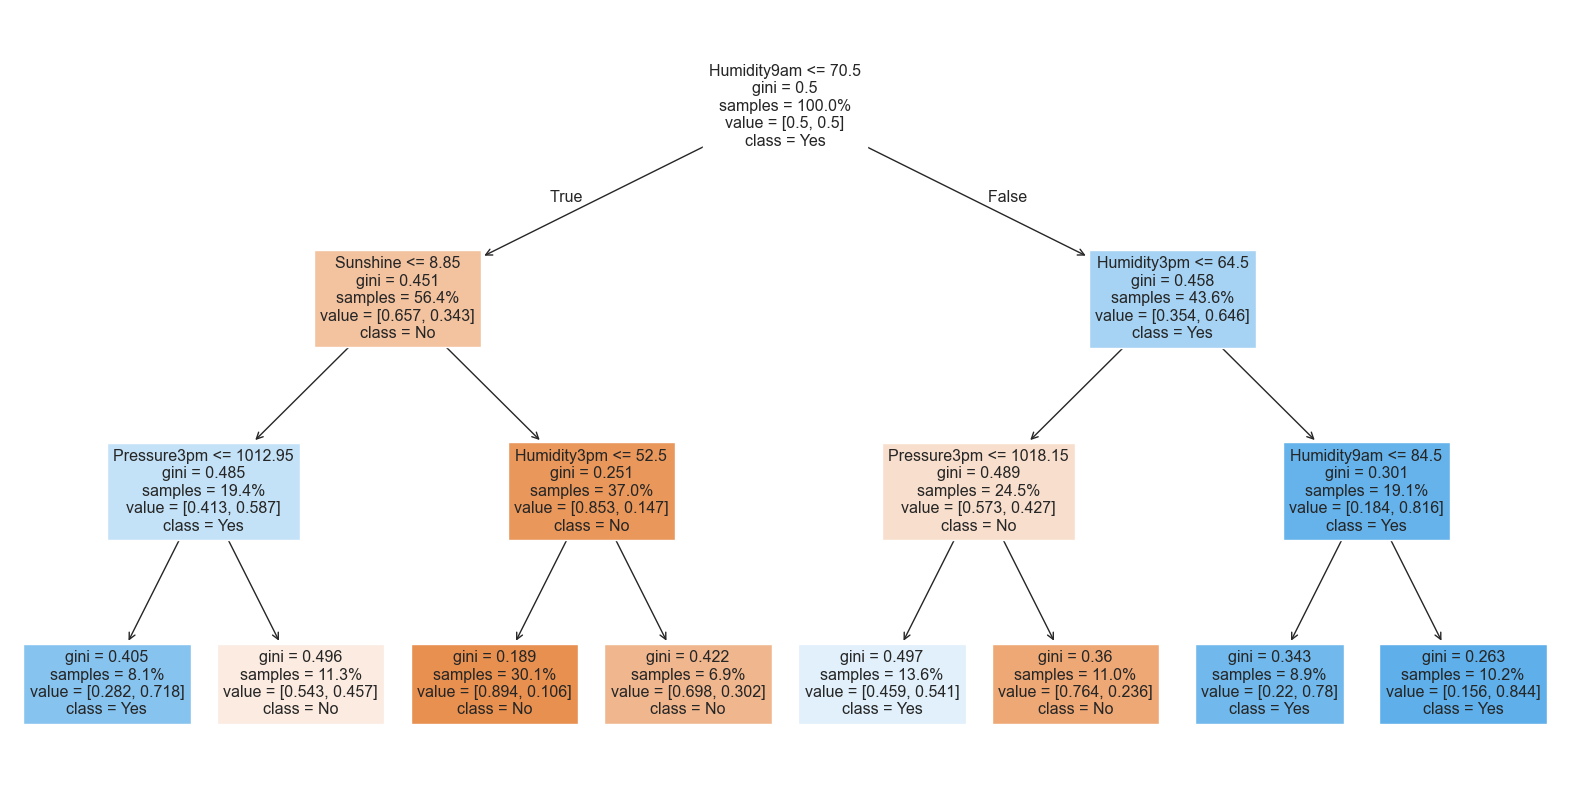

In [11]:
# Equilibrar las clases
X = df[['MinTemp', 'MaxTemp', 'Rainfall','Sunshine', 'Humidity9am', 'Humidity3pm',
        'Pressure3pm', 'Cloud3pm']]
y = df['RainTomorrow']

# Eliminar filas con NaN en las variables
X = X.apply(pd.to_numeric, errors='coerce')
X = X.dropna()

# Mantener las mismas filas en y
y = y.loc[X.index]

# Codificar etiquetas
le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.5, random_state=42)

clf = DecisionTreeClassifier(max_depth=3,max_features='sqrt',class_weight='balanced',min_weight_fraction_leaf=0.01, random_state=42)
clf.fit(X_train, y_train)

plt.figure(figsize=(20,10))
plot_tree(clf, feature_names=X.columns, class_names=le.classes_, filled=True,proportion=True)
plt.show()

Precisión del modelo: 0.7140993383654832


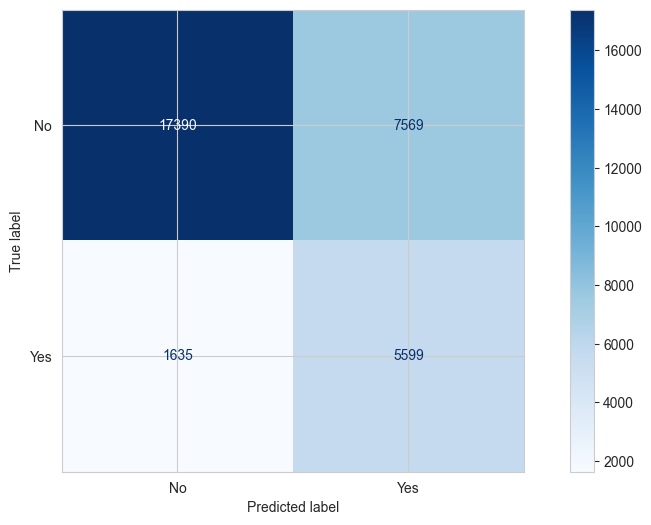

In [12]:
# Predicciones
y_pred = clf.predict(X_test)

# Precisión
accuracy = accuracy_score(y_test, y_pred)
print("Precisión del modelo:", accuracy)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=le.classes_,
    cmap="Blues"
)
plt.show()

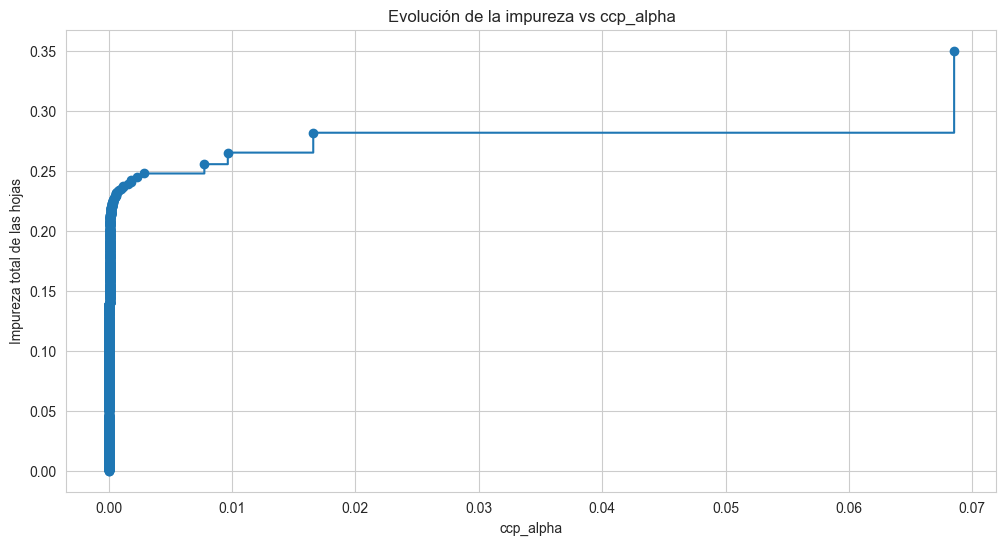

In [13]:
# realizar poda del arbol para penalizar la complejidad

path = DecisionTreeClassifier(random_state=0).cost_complexity_pruning_path(X_train, y_train)

ccp_alphas = path.ccp_alphas
impurities = path.impurities

plt.figure()
plt.plot(ccp_alphas, impurities, marker='o', drawstyle="steps-post")
plt.xlabel("ccp_alpha")
plt.ylabel("Impureza total de las hojas")
plt.title("Evolución de la impureza vs ccp_alpha")
plt.show()

Precisión del modelo: 0.7826546143571584
--- INFORME DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

           0       0.93      0.78      0.85     24959
           1       0.51      0.80      0.62      7234

    accuracy                           0.78     32193
   macro avg       0.72      0.79      0.74     32193
weighted avg       0.84      0.78      0.80     32193



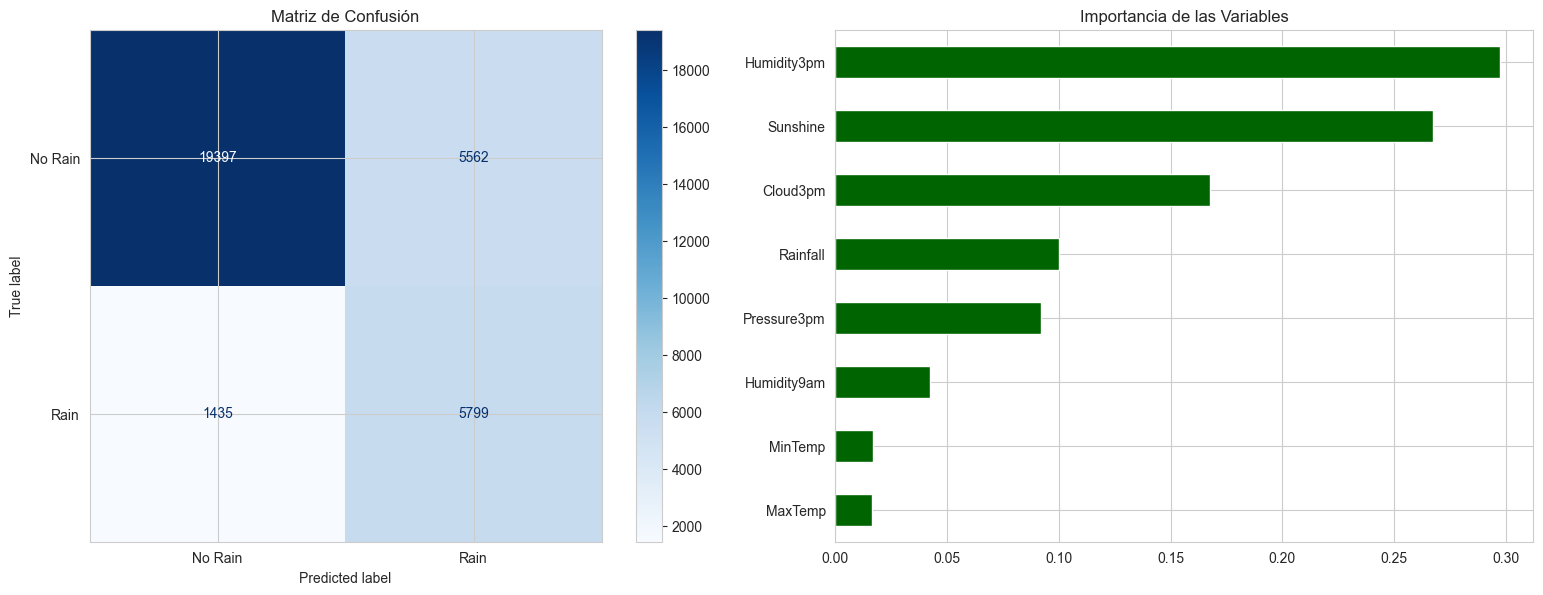

In [14]:
# Random forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# 'balanced_subsample' es ideal para datasets con mucha diferencia entre clases
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    max_features='sqrt',
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1  # Usa todos los núcleos de tu procesador para ir más rápido
)

rf.fit(X_train, y_train)

# Precisión
y_pred = rf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Precisión del modelo:", accuracy)


# Evaluación
print("--- INFORME DE CLASIFICACIÓN ---")
print(classification_report(y_test, y_pred))

# Visualización: Matriz de Confusión y Variables Importantes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Matriz de Confusión (Para ver aciertos y fallos reales)
ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test,
                                      display_labels=['No Rain', 'Rain'],
                                      cmap='Blues', ax=ax1)
ax1.set_title("Matriz de Confusión")

# Ranking de variables
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)
importances.plot(kind='barh', color='darkgreen', ax=ax2)
ax2.set_title("Importancia de las Variables")

plt.tight_layout()
plt.show()